In [7]:
import os

PROJECT_ROOT = '/home/user/projects/SoftStairs-QAT'
LOG_ROOT     = os.path.join(PROJECT_ROOT, 'experiments', 'CV', 'logs')

os.makedirs(LOG_ROOT, exist_ok=True)
print("LOG_ROOT:", LOG_ROOT)

DATASET = 'TinyImageNet'

import torch
import torchvision.models as models
import torch.nn as nn


def get_inception(n_classes):
    model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, n_classes)
    model.aux_logits = False
    if model.aux_logits:
        model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, n_classes)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    return model

LOG_ROOT: /home/user/projects/SoftStairs-QAT/experiments/CV/logs


In [8]:
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset
import pytorch_lightning as pl

test_transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop((299, 299), scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

DATASET_PATH = os.path.expanduser('~/projects/SoftStairs-QAT/data/tiny-imagenet-200')
BATCH_SIZE = 32

IMG_EXT = ('.jpg', '.jpeg', '.png', '.ppm', '.bmp', '.pgm', '.tif', '.tiff', '.webp')
def is_valid_file(path):
    return path.lower().endswith(IMG_EXT)

train_dataset = ImageFolder(
    root=os.path.join(DATASET_PATH, 'train'),
    transform=train_transform,
    is_valid_file=is_valid_file,
)
val_dataset = ImageFolder(
    root=os.path.join(DATASET_PATH, 'val'),
    transform=test_transform,
    is_valid_file=is_valid_file,
)

pl.seed_everything(42)

print("train classes:", len(train_dataset.classes))
print("val classes:  ", len(val_dataset.classes))
print("train size:   ", len(train_dataset))
print("val size:     ", len(val_dataset))

# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
#                           drop_last=True, pin_memory=True, num_workers=4)
# val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
#                           drop_last=False, num_workers=4)
N_TRAIN_SUBSET = 10000
N_VAL_SUBSET   = 5000

train_subset = Subset(train_dataset, list(range(N_TRAIN_SUBSET)))
val_subset   = Subset(val_dataset,   list(range(N_VAL_SUBSET)))

train_loader = DataLoader(
    train_subset, batch_size=BATCH_SIZE, shuffle=True,
    drop_last=True, pin_memory=True, num_workers=4,
)
val_loader = DataLoader(
    val_subset, batch_size=BATCH_SIZE, shuffle=False,
    drop_last=False, num_workers=4,
)

print()
print(f"train subset: {len(train_subset)}  / {len(train_loader)} batch")
print(f"val subset:   {len(val_subset)}  / {len(val_loader)} batch ")

Seed set to 42


train classes: 200
val classes:   200
train size:    100000
val size:      10000

train subset: 10000  / 312 batch
val subset:   5000  / 157 batch 


In [9]:
import torch

def reset_specific_gpu(gpu_id=0):
    if torch.cuda.is_available():
        with torch.cuda.device(gpu_id):
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()
            torch.cuda.synchronize()
            print(f"GPU {gpu_id} reset")
            print(f"Memory allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

reset_specific_gpu(0)

example_batch = next(iter(train_loader))
print(example_batch[0].shape, example_batch[1].shape)

del example_batch
torch.cuda.empty_cache()

GPU 0 reset
Memory allocated: 0.00 GB
torch.Size([32, 3, 299, 299]) torch.Size([32])


In [10]:
from softstairs_qat import SoftStairsQuantizer, QuantizationConfig
import pytorch_lightning as pl


class SSQStep(pl.Callback):
    def on_train_epoch_start(self, trainer, pl_module):
        epoch = trainer.current_epoch
        if not pl_module.quantizer:
            return
        if epoch > 0:
            pl_module.quantizer.step()
        t_value = pl_module.quantizer.t
        pl_module.log('quantizer_t', t_value, on_epoch=True, on_step=False)
        pl_module.log('quantizer_tback', pl_module.quantizer.current_backward_t,
                      on_step=False)

    def on_validation_epoch_start(self, trainer, pl_module):
        if pl_module.quantizer:
            t_value = pl_module.quantizer.t
            pl_module.log('quantizer_t', t_value, on_epoch=True, on_step=False)
            pl_module.log('quantizer_tback', pl_module.quantizer.current_backward_t,
                          on_step=False)

W0921 11:46:11.353000 2043 torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
W0921 11:46:11.382000 2043 torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.


In [5]:
from torchao.quantization import quantize_

In [11]:
from torch.ao.quantization import QConfig
from torch.ao.quantization.fake_quantize import FakeQuantize
from torch.ao.quantization.observer import HistogramObserver, PlaceholderObserver


def get_weight_only_qconfig(bit_width=8):
    if bit_width == 8:
        weight_fake_quant = FakeQuantize.with_args(
            observer=HistogramObserver,
            quant_min=-128, quant_max=127,
            dtype=torch.qint8, qscheme=torch.per_tensor_affine,
        )
    elif bit_width == 4:
        weight_fake_quant = FakeQuantize.with_args(
            observer=HistogramObserver,
            quant_min=-8, quant_max=7,
            dtype=torch.qint8, qscheme=torch.per_tensor_affine,
        )
    else:
        raise ValueError(f"Unsupported bit width: {bit_width}")

    activation_fake_quant = PlaceholderObserver.with_args(
        dtype=torch.float32, is_dynamic=False,
    )
    return QConfig(activation=activation_fake_quant, weight=weight_fake_quant)


qconfig_weight_only = get_weight_only_qconfig(8)
qconfig_weight_only_int4 = get_weight_only_qconfig(4)

In [12]:
import torch
from torchmetrics import Metric


class ClassificationMargin(Metric):
    def __init__(self, dist_sync_on_step=False):
        super().__init__(dist_sync_on_step=dist_sync_on_step)
        self.add_state("margin_sum", default=torch.tensor(0.0), dist_reduce_fx="sum")
        self.add_state("n", default=torch.tensor(0), dist_reduce_fx="sum")

    def update(self, logits: torch.Tensor, target: torch.Tensor):
        true_logit = logits.gather(1, target.unsqueeze(1)).squeeze(1)
        masked = logits.clone()
        masked.scatter_(1, target.unsqueeze(1), float('-inf'))
        max_other = masked.max(dim=1).values
        margin = true_logit - max_other
        self.margin_sum += margin.sum()
        self.n += margin.numel()

    def compute(self):
        return self.margin_sum / self.n.clamp(min=1)


class LogitNormDiff(Metric):
    def __init__(self, dist_sync_on_step=False):
        super().__init__(dist_sync_on_step=dist_sync_on_step)
        self.add_state("norm_sum", default=torch.tensor(0.0), dist_reduce_fx="sum")
        self.add_state("n", default=torch.tensor(0), dist_reduce_fx="sum")

    def update(self, logits: torch.Tensor):
        centered = logits - logits.mean(dim=1, keepdim=True)
        norm = centered.norm(p=2, dim=1)
        self.norm_sum += norm.sum()
        self.n += norm.numel()

    def compute(self):
        return self.norm_sum / self.n.clamp(min=1)

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import pytorch_lightning as pl
from torchmetrics import MetricCollection
from torchmetrics.classification import Accuracy, F1Score, ConfusionMatrix


class TinyImageNetModule(pl.LightningModule):
    def __init__(self, model_name, model_hparams, optimizer_name, optimizer_hparams,
                 fake_quant=False, torch_qat=False, quantization_hparams={}):
        super().__init__()
        self.save_hyperparameters()

        n_classes = self.hparams.model_hparams['n_classes']
        self.model = get_inception(n_classes)

        if hasattr(self.model, 'aux_logits'):
            self.model.aux_logits = True

        self.torch_qat = torch_qat
        self.fake_quant = fake_quant

        self._prepare_quantization()

        self.loss_module = nn.CrossEntropyLoss()

        self.train_metrics = MetricCollection({
            'mtr/acc': Accuracy(task="multiclass", num_classes=n_classes),
            'mtr/f1':  F1Score(task="multiclass", num_classes=n_classes, average='macro'),
        })
        self.val_metrics = MetricCollection({
            'mtr/acc': Accuracy(task="multiclass", num_classes=n_classes),
            'mtr/f1':  F1Score(task="multiclass", num_classes=n_classes, average='macro'),
        })
        self.test_metrics = MetricCollection({
            'mtr/acc': Accuracy(task="multiclass", num_classes=n_classes),
            'mtr/f1':  F1Score(task="multiclass", num_classes=n_classes, average='macro'),
        })

        self.train_margin  = ClassificationMargin()
        self.train_lognorm = LogitNormDiff()
        self.val_margin    = ClassificationMargin()
        self.val_lognorm   = LogitNormDiff()

        if self.fake_quant:
            self.val_metrics_quant = MetricCollection({
                'mtr/acc_quant': Accuracy(task="multiclass", num_classes=n_classes),
                'mtr/f1_quant':  F1Score(task="multiclass", num_classes=n_classes,
                                         average='macro'),
            })
            self.val_margin_quant  = ClassificationMargin()
            self.val_lognorm_quant = LogitNormDiff()

        self.val_confusion  = ConfusionMatrix(task="multiclass", num_classes=n_classes)
        self.test_confusion = ConfusionMatrix(task="multiclass", num_classes=n_classes)
        self.example_input_array = torch.zeros((1, 3, 299, 299), dtype=torch.float32)

    def _prepare_quantization(self):
        self.quantizer = None
        if self.torch_qat:
            from torch.quantization import prepare_qat
            n_bits = self.hparams.quantization_hparams['n_bits']
            qconfig = get_weight_only_qconfig(n_bits)
            self.model.qconfig = qconfig
            prepare_qat(self.model, inplace=True)
        else:
            excluded_modules = {
                n for n, _ in self.model.named_modules()
                if "bn" in n or "aux" in n.lower()
            }
            qconfig = QuantizationConfig(**self.hparams.quantization_hparams)
            self.quantizer = SoftStairsQuantizer(
                self.model, qconfig, excluded_modules=excluded_modules,
            )

    def forward(self, imgs):
        if self.training and hasattr(self.model, 'aux_logits') and self.model.aux_logits:
            output, aux_output = self.model(imgs)
            return output, aux_output
        return self.model(imgs)

    def configure_optimizers(self):
        if self.hparams.optimizer_name == "Adam":
            optimizer = optim.AdamW(self.parameters(), **self.hparams.optimizer_hparams)
        elif self.hparams.optimizer_name == "SGD":
            optimizer = optim.SGD(self.parameters(), **self.hparams.optimizer_hparams)
        else:
            assert False, f'Unknown optimizer: "{self.hparams.optimizer_name}"'

        scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=[20, 27], gamma=0.1)
        return [optimizer], [scheduler]

    def training_step(self, batch, batch_idx):
        imgs, labels = batch
        if hasattr(self.model, 'aux_logits') and self.model.aux_logits:
            logits, aux_logits = self.model(imgs)
            loss1 = self.loss_module(logits, labels)
            loss2 = self.loss_module(aux_logits, labels)
            loss = loss1 + 0.4 * loss2
        else:
            logits = self.model(imgs)
            loss = self.loss_module(logits, labels)

        preds = logits.argmax(-1)
        self.train_metrics.update(preds, labels)
        self.train_margin.update(logits.detach(), labels)
        self.train_lognorm.update(logits.detach())

        self.log_dict(self.train_metrics, on_step=True, on_epoch=True, prog_bar=True)
        self.log('loss/train', loss, on_step=True, on_epoch=True, prog_bar=False)
        self.log('mtr/margin',  self.train_margin,  on_step=False, on_epoch=True, prog_bar=False)
        self.log('mtr/lognorm', self.train_lognorm, on_step=False, on_epoch=True, prog_bar=False)
        return loss

    def on_train_epoch_start(self):
        if self.quantizer:
            self.log('epoch_start_quant_error',
                     self.quantizer.estimate_current_quant_error(),
                     on_epoch=True, prog_bar=True)

    def on_train_epoch_end(self):
        if self.quantizer:
            self.log('epoch_end_quant_error',
                     self.quantizer.estimate_current_quant_error(),
                     on_epoch=True, prog_bar=True)
        self.train_metrics.reset()
        self.train_margin.reset()
        self.train_lognorm.reset()

    def validation_step(self, batch, batch_idx):
        imgs, labels = batch

        if hasattr(self.model, 'aux_logits'):
            self.model.aux_logits = False

        logits = self.model(imgs)
        loss = self.loss_module(logits, labels)
        preds = logits.argmax(-1)

        self.val_metrics.update(preds, labels)
        self.val_margin.update(logits.detach(), labels)
        self.val_lognorm.update(logits.detach())

        self.log_dict(self.val_metrics, on_step=False, on_epoch=True, prog_bar=True)
        self.log("loss/val", loss, on_epoch=True, on_step=False)
        self.log('mtr/val_margin',  self.val_margin,  on_step=False, on_epoch=True, prog_bar=False)
        self.log('mtr/val_lognorm', self.val_lognorm, on_step=False, on_epoch=True, prog_bar=False)

        if hasattr(self.model, 'aux_logits'):
            self.model.aux_logits = True

        if not (self.fake_quant and self.quantizer):
            return loss

        if (batch_idx + 1) == self.trainer.num_val_batches[0]:
            state_dict = {k: v.clone() for k, v in self.model.state_dict().items()}
            self.quantizer.fake_quantize()
            with torch.no_grad():
                logits_q = self.model(imgs)
            preds_q = logits_q.argmax(-1)
            self.val_metrics_quant.update(preds_q, labels)
            self.val_margin_quant.update(logits_q.detach(), labels)
            self.val_lognorm_quant.update(logits_q.detach())

            self.log_dict(self.val_metrics_quant, on_step=False, on_epoch=True,
                          prog_bar=True)
            self.log('mtr/val_margin_quant',  self.val_margin_quant,
                     on_step=False, on_epoch=True, prog_bar=False)
            self.log('mtr/val_lognorm_quant', self.val_lognorm_quant,
                     on_step=False, on_epoch=True, prog_bar=False)

            self.model.load_state_dict(state_dict)
            del state_dict
            self.quantizer.activate_hooks()

        return loss

    def on_validation_epoch_end(self):
        self.val_metrics.reset()
        self.val_margin.reset()
        self.val_lognorm.reset()
        # ИЗМЕНЕНИЕ: сброс quant-метрик через hasattr
        if hasattr(self, 'val_metrics_quant'):
            self.val_metrics_quant.reset()
            self.val_margin_quant.reset()
            self.val_lognorm_quant.reset()
        torch.cuda.empty_cache()
        import gc
        gc.collect()

    def test_step(self, batch, batch_idx):
        imgs, labels = batch
        if hasattr(self.model, 'aux_logits'):
            self.model.aux_logits = False
        logits = self.model(imgs)
        preds = logits.argmax(-1)
        self.test_metrics.update(preds, labels)
        self.log_dict(self.test_metrics, on_step=False, on_epoch=True)

    def on_test_epoch_end(self):
        self.test_metrics.reset()

In [14]:
from pytorch_lightning.callbacks import LearningRateMonitor, Callback
from pytorch_lightning.loggers import CSVLogger
from pytorch_lightning.callbacks import TQDMProgressBar


class GradSaver(Callback):
    def __init__(self, parameter_name):
        self.parameter_name = parameter_name
        self.save_dir = parameter_name
        self.epoch_counter = 0
        self.hook = None
        self.grad = None
        self.log_dir = None
        self.parameter = None

    def on_fit_start(self, trainer, pl_module):
        part = pl_module.model
        for name in self.parameter_name.split('.'):
            part = getattr(part, name)
        self.parameter = part
        self.parameter.requires_grad_ = True

        def gather_grad(param):
            self.grad = param.grad
        self.hook = self.parameter.register_post_accumulate_grad_hook(gather_grad)

    def on_train_epoch_end(self, trainer, pl_module):
        if not pl_module.quantizer:
            return
        if self.log_dir is None:
            self.log_dir = os.path.join(trainer.log_dir, self.save_dir)
            os.makedirs(self.log_dir, exist_ok=True)
        if self.grad is not None:
            torch.save(self.grad.detach().cpu(),
                       os.path.join(self.log_dir, f'grad_{pl_module.current_epoch}.pth'))
        torch.save(
            pl_module.quantizer.upscaled_parameter(
                self.parameter_name + pl_module.quantizer._orig_suffix
            ).detach().cpu(),
            os.path.join(self.log_dir, f'param_{pl_module.current_epoch}.pth'),
        )
        self.epoch_counter += 1

    def on_fit_end(self, trainer, pl_module):
        if self.hook:
            self.hook.remove()


def train_model(model_name, save_name=None, epochs=100, torch_qat=False,
                quantization_hparams={}, retrain=False, **kwargs):
    if save_name is None:
        save_name = model_name

    logger = CSVLogger(save_dir=LOG_ROOT, name=save_name)

    trainer = pl.Trainer(
        accelerator="auto",
        devices=1,
        max_epochs=epochs,
        enable_checkpointing=False,
        callbacks=[
            SSQStep(),
            LearningRateMonitor("epoch"),
            GradSaver('fc.weight'),
            TQDMProgressBar(refresh_rate=10),
        ],
        logger=logger,
    )
    trainer.logger._default_hp_metric = None

    pl.seed_everything(42)
    model = TinyImageNetModule(
        model_name=model_name,
        quantization_hparams=quantization_hparams | {'n_steps': epochs + 1},
        torch_qat=torch_qat,
        **kwargs,
    )
    trainer.fit(model, train_loader, val_loader)

    return model

## training

In [ ]:
# MODEL_NAME = 'InceptionNet'
# N_BITS = 4
# TYPE = 'torch'
# N_EPOCHS = 1
# ASYNC = 1
# STRATEGY = 'cyclic'

# SAVE_NAME = f"{MODEL_NAME}_{DATASET}_str{STRATEGY}_af{ASYNC}_b{N_BITS}_t{TYPE}"

In [ ]:
# model = train_model(
#     model_name=MODEL_NAME,
#     save_name=SAVE_NAME,
#     model_hparams={"n_classes": 200},
#     optimizer_name="Adam",
#     optimizer_hparams={"lr": 1e-3, "weight_decay": 0.},
#     quantization_hparams=dict(
#         t_scheduler_strategy=STRATEGY,
#         async_t_factor=ASYNC,
#         t_start=0.9,
#         t_end=0.0005,
#         n_bits=N_BITS,
#         type=TYPE,
#         normalized=True,
#         symmetric=False,
#         half_shift=False,
#     ),
#     torch_qat='torch' in TYPE,
#     retrain=True,
#     fake_quant=True,
#     epochs=N_EPOCHS,
# )

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 42
/tmp/ipykernel_1139/1545881884.py:68: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorc

┏━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃    ┃ Name              ┃ Type                      ┃ Params ┃ Mode  ┃  FLOPs ┃         In sizes ┃ Out sizes ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ 0  │ model             │ Inception3                │ 24.9 M │ train │ 11.4 B │ [1, 3, 299, 299] │  [1, 200] │
│ 1  │ loss_module       │ CrossEntropyLoss          │      0 │ train │      0 │                ? │         ? │
│ 2  │ train_metrics     │ MetricCollection          │      0 │ train │      0 │                ? │         ? │
│ 3  │ val_metrics       │ MetricCollection          │      0 │ train │      0 │                ? │         ? │
│ 4  │ test_metrics      │ MetricCollection          │      0 │ train │      0 │                ? │         ? │
│ 5  │ train_margin      │ ClassificationMargin      │      0 │ train │      0 │                ? │         ? │
│ 6  │ train_lognorm     │ LogitNormDiff             │      0 │ train │      0 │                ? │         ? │
│ 7  │ val_margin        │ ClassificationMargin      │      0 │ train │      0 │                ? │         ? │
│ 8  │ val_lognorm       │ LogitNormDiff             │      0 │ train │      0 │                ? │         ? │
│ 9  │ val_metrics_quant │ MetricCollection          │      0 │ train │      0 │                ? │         ? │
│ 10 │ val_margin_quant  │ ClassificationMargin      │      0 │ train │      0 │                ? │         ? │
│ 11 │ val_lognorm_quant │ LogitNormDiff             │      0 │ train │      0 │                ? │         ? │
│ 12 │ val_confusion     │ MulticlassConfusionMatrix │      0 │ train │      0 │                ? │         ? │
│ 13 │ test_confusion    │ MulticlassConfusionMatrix │      0 │ train │      0 │                ? │         ? │
└────┴───────────────────┴───────────────────────────┴────────┴───────┴────────┴──────────────────┴───────────┘

Trainable params: 24.9 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 24.9 M                                                                                               
Total estimated model params size (MB): 99.627                                                                     
Modules in train mode: 718                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 11.4 B

In [44]:
MODEL_NAME = 'InceptionNet'
N_BITS = 8
TYPE = 'standard'
N_EPOCHS = 15
ASYNC = 1
STRATEGY = 'cyclic'

SAVE_NAME = f"{MODEL_NAME}_{DATASET}_str{STRATEGY}_af{ASYNC}_b{N_BITS}_t{TYPE}_SUBSAMPLE"

model = train_model(
    model_name=MODEL_NAME,
    save_name=SAVE_NAME,
    model_hparams={"n_classes": 200},
    optimizer_name="Adam",
    optimizer_hparams={"lr": 1e-3, "weight_decay": 0.},
    quantization_hparams=dict(
        t_scheduler_strategy=STRATEGY,
        async_t_factor=ASYNC,
        t_start=0.9,
        t_end=0.0005,
        n_bits=N_BITS,
        type=TYPE,
        normalized=True,
        symmetric=False,
        half_shift=False,
    ),
    torch_qat='torch' in TYPE,
    retrain=True,
    fake_quant=True,
    epochs=N_EPOCHS,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 42


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┓
┃    ┃ Name              ┃ Type                      ┃ Params ┃ Mode  ┃  FLOPs ┃         In sizes ┃ Out sizes ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━┩
│ 0  │ model             │ Inception3                │ 25.5 M │ train │ 11.4 B │ [1, 3, 299, 299] │  [1, 200] │
│ 1  │ loss_module       │ CrossEntropyLoss          │      0 │ train │      0 │                ? │         ? │
│ 2  │ train_metrics     │ MetricCollection          │      0 │ train │      0 │                ? │         ? │
│ 3  │ val_metrics       │ MetricCollection          │      0 │ train │      0 │                ? │         ? │
│ 4  │ test_metrics      │ MetricCollection          │      0 │ train │      0 │                ? │         ? │
│ 5  │ train_margin      │ ClassificationMargin      │      0 │ train │      0 │                ? │         ? │
│ 6  │ train_lognorm     │ LogitNormDiff             │      0 │ train │      0 │                ? │         ? │
│ 7  │ val_margin        │ ClassificationMargin      │      0 │ train │      0 │                ? │         ? │
│ 8  │ val_lognorm       │ LogitNormDiff             │      0 │ train │      0 │                ? │         ? │
│ 9  │ val_metrics_quant │ MetricCollection          │      0 │ train │      0 │                ? │         ? │
│ 10 │ val_margin_quant  │ ClassificationMargin      │      0 │ train │      0 │                ? │         ? │
│ 11 │ val_lognorm_quant │ LogitNormDiff             │      0 │ train │      0 │                ? │         ? │
│ 12 │ val_confusion     │ MulticlassConfusionMatrix │      0 │ train │      0 │                ? │         ? │
│ 13 │ test_confusion    │ MulticlassConfusionMatrix │      0 │ train │      0 │                ? │         ? │
└────┴───────────────────┴───────────────────────────┴────────┴───────┴────────┴──────────────────┴───────────┘

Trainable params: 25.5 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 25.5 M                                                                                               
Total estimated model params size (MB): 102.088                                                                    
Modules in train mode: 328                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 11.4 B

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=15` reached.


In [42]:
from pathlib import Path
import pandas as pd
import numpy as np

def read_results(name, scale='step', version=None, agg_func='last'):
    path = Path(LOG_ROOT) / name
    if not path.exists():
        available = sorted(os.listdir(LOG_ROOT)) if os.path.isdir(LOG_ROOT) else []
        raise FileNotFoundError(
            f"Нет папки: {path}\n"
            f"LOG_ROOT = {LOG_ROOT}\n"
            f"Доступные: {available}"
        )
    if not version:
        version = sorted(os.listdir(path), key=lambda x: float(x.split('_')[-1]))[-1]
    elif isinstance(version, int):
        version = f'version_{version}'
    file = path / version / 'metrics.csv'
    df = pd.read_csv(file)

    keep = []
    for c in df.columns:
        if c.endswith('_epoch'):
            keep.append(c)
        elif c in ('epoch', 'step',
                   'lr-AdamW',
                   'quantizer_t', 'quantizer_tback',
                   'loss/val', 'loss/val_quant',
                   'mtr/margin', 'mtr/lognorm',                 
                   'mtr/val_margin', 'mtr/val_lognorm',
                   'mtr/val_margin_quant', 'mtr/val_lognorm_quant',
                   'mtr/val_acc', 'mtr/val_f1',
                   'epoch_start_quant_error', 'epoch_end_quant_error'):
            keep.append(c)
    df = df[keep]
    def last_valid(s):
        s = s.dropna()
        return s.iloc[-1] if len(s) else np.nan

    df = df.groupby(scale).agg(last_valid).reset_index()
    alternative_scale = 'step' if scale != 'step' else 'epoch'
    df.drop([c for c in df.columns if alternative_scale in c], axis=1, inplace=True)
    return df, 0.0

array([[<Axes: title={'center': 'losses'}, xlabel='epoch', ylabel='loss/train_epoch'>,
        <Axes: title={'center': 'metrics'}, xlabel='epoch', ylabel='mtr/lognorm'>],
       [<Axes: title={'center': 't_schedule'}, xlabel='epoch', ylabel='quantizer_t'>,
        <Axes: title={'center': 'lognorm vs. t_schedule'}, xlabel='quantizer_t', ylabel='mtr/lognorm'>]],
      dtype=object)

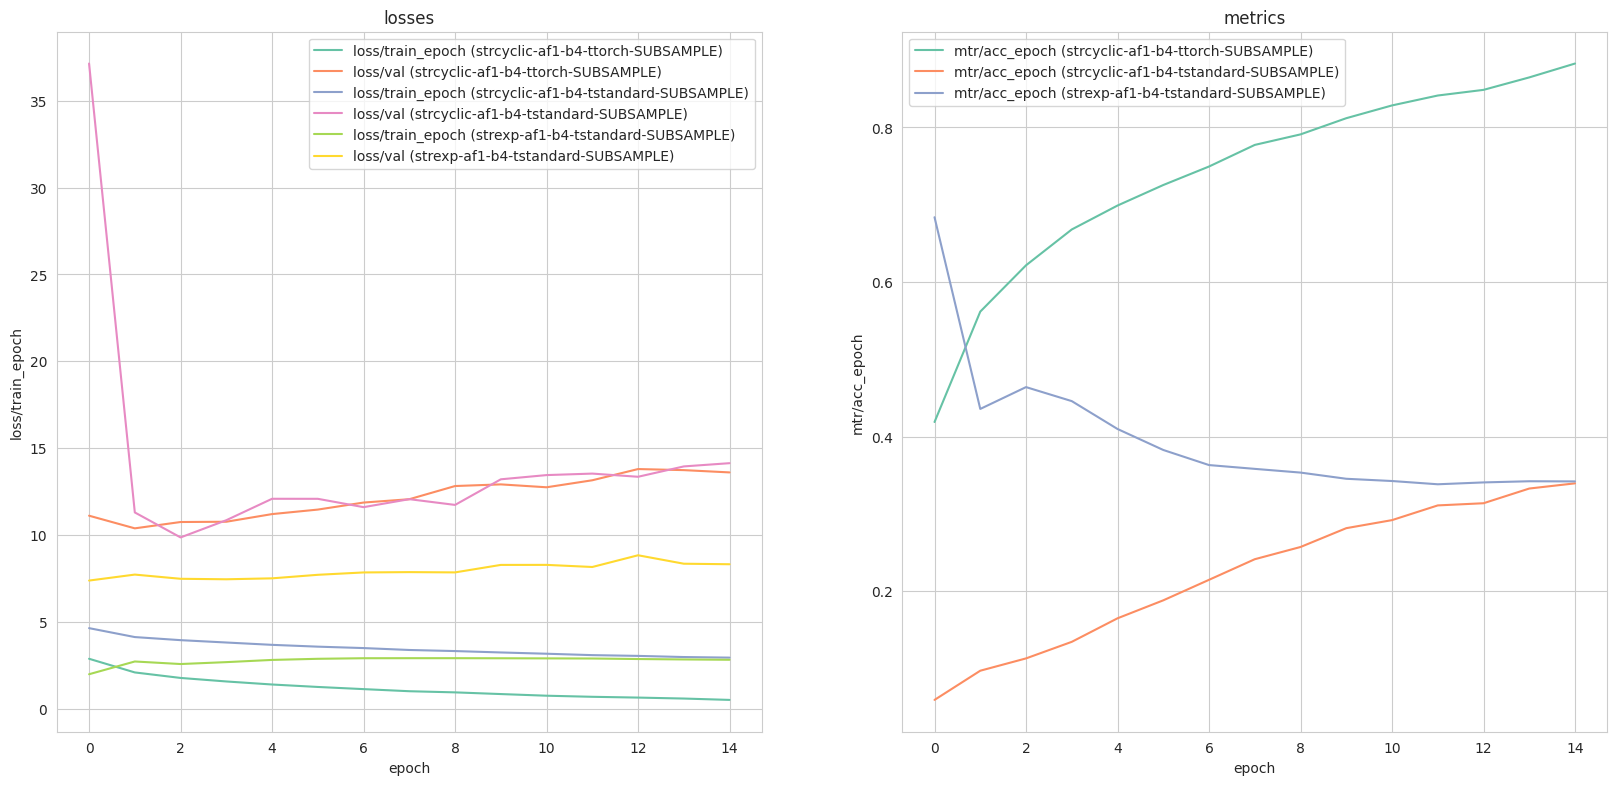

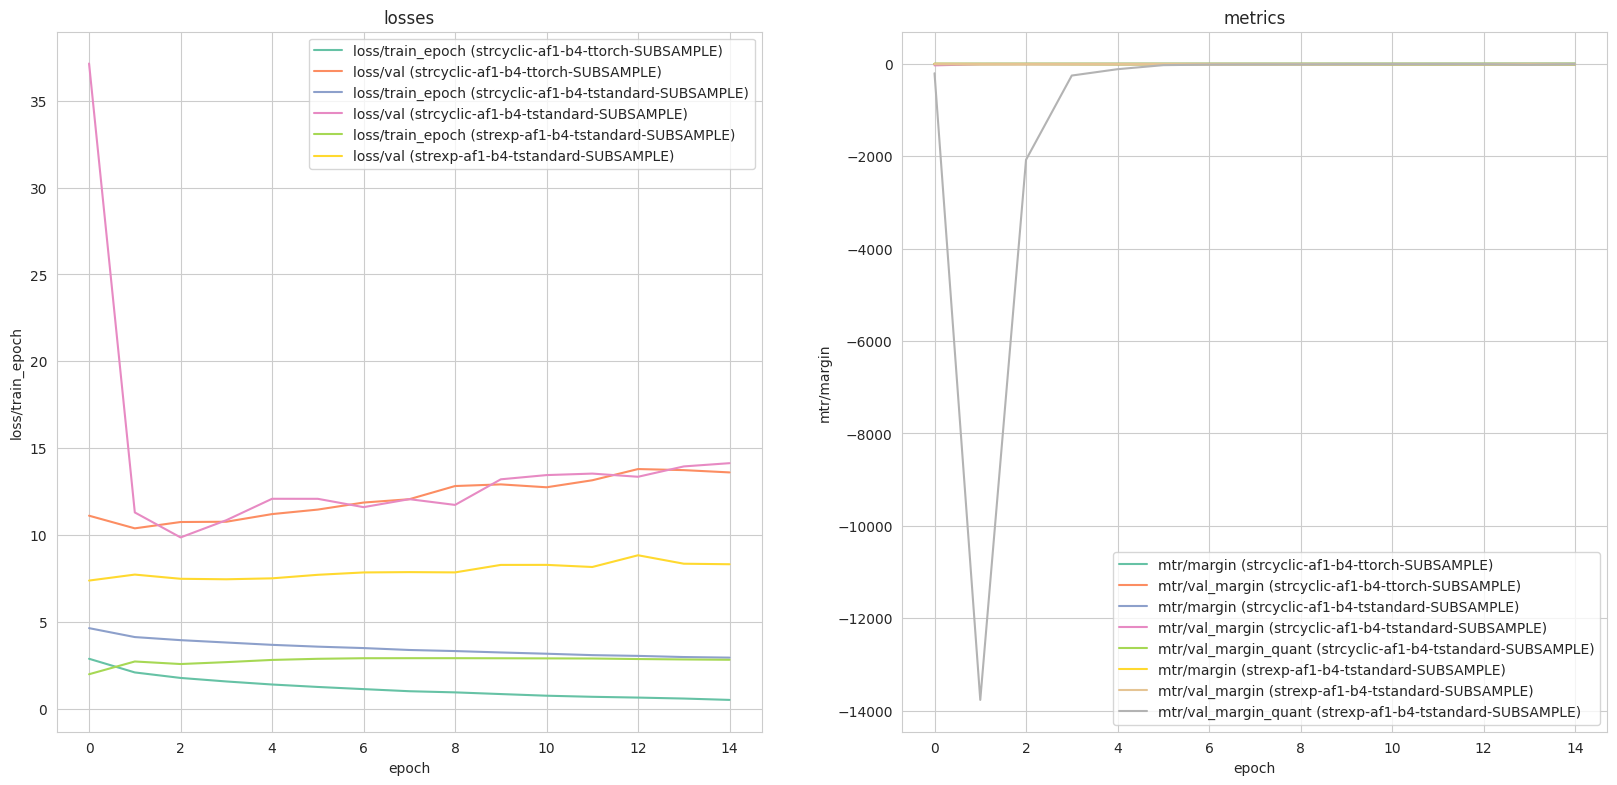

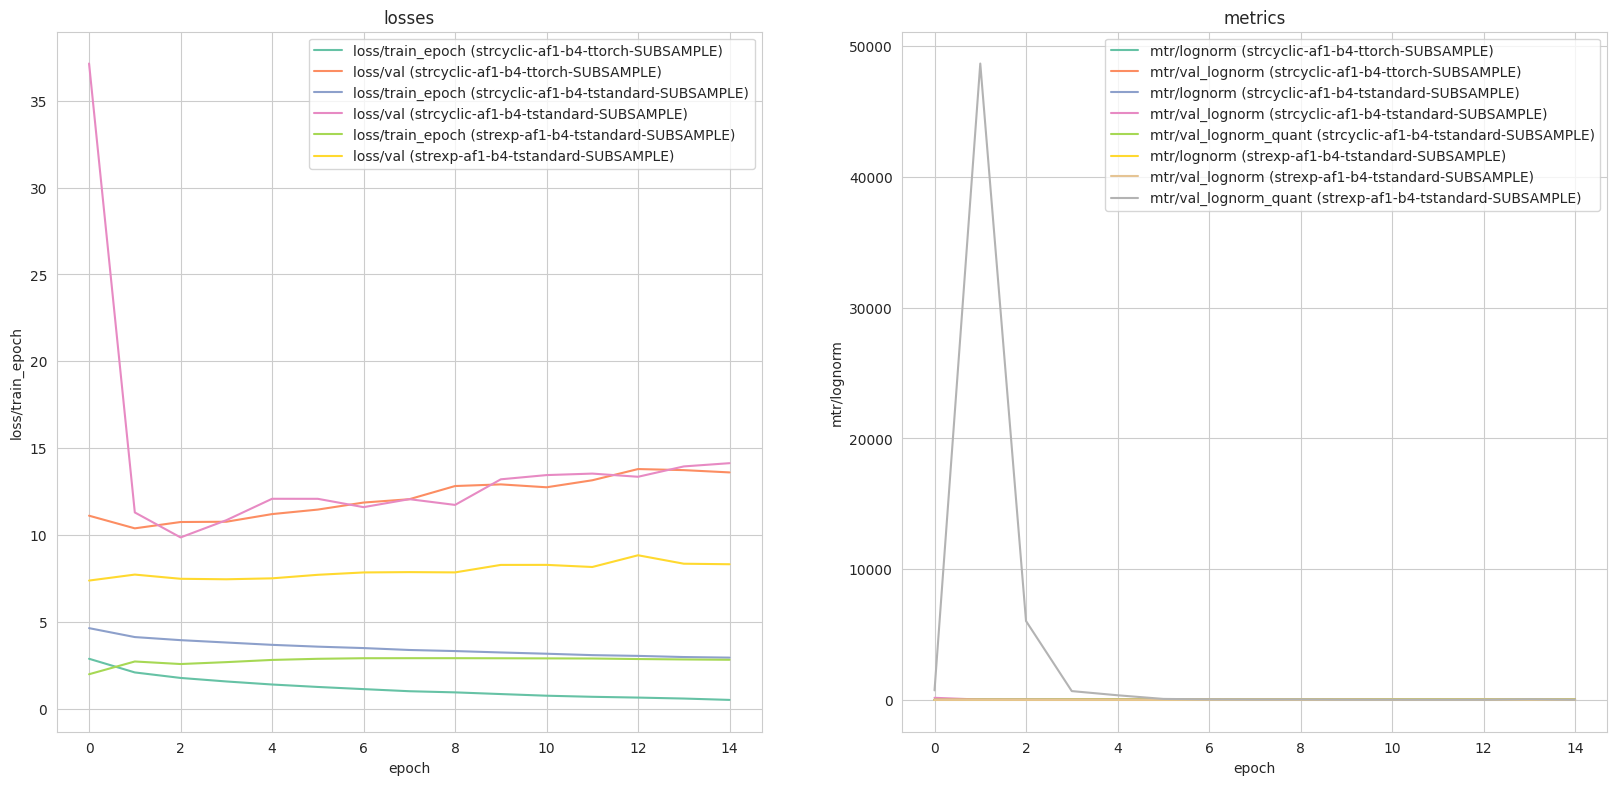

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_palette("Set2")


def plot_dynamics(name, scale='step', metric='acc', axes=None, suffix='',
                  agg_func='mean'):
    name, *version = name.split('#')
    version = int(version[0]) if version else None
    dynamics, final_results = read_results(name, scale, version, agg_func)

    if axes is None:
        fig, axes = plt.subplots(2, 2, figsize=(20, 20))

    for c in [c for c in dynamics.columns if c.startswith('loss/')]:
        sns.lineplot(dynamics, x=scale, y=c, ax=axes[0][0], label=c + suffix)
    axes[0][0].legend()
    axes[0][0].set_title('losses')

    metric_cols = [
        c for c in dynamics.columns
        if (metric is None and c.startswith('mtr/'))
        or (isinstance(metric, str) and metric in c)
    ]
    for c in metric_cols:
        sns.lineplot(dynamics, x=scale, y=c, ax=axes[0][1], label=c + suffix)
    axes[0][1].legend()
    axes[0][1].set_title('metrics')

    if 'quantizer_t' in dynamics.columns:
        ax = axes[1][0]
        sns.lineplot(dynamics, x=scale, y='quantizer_t', ax=ax, label='t' + suffix)
        if 'quantizer_tback' in dynamics.columns:
            sns.lineplot(dynamics, x=scale, y='quantizer_tback', ax=ax,
                         label='tback' + suffix)
        ax.set_title('t_schedule')

        ax = axes[1][1]
        for c in metric_cols:
            sns.scatterplot(dynamics, x='quantizer_t', y=c, ax=ax,
                            label=c + suffix)
        ax.set_title(f'{metric} vs. t_schedule')
    else:
        axes[1][0].set_visible(False)
        axes[1][1].set_visible(False)

    return axes


def plot_comparison(*exps, scale, metric, suffixes=None, agg_func='mean'):
    if suffixes is None:
        suffixes = [f" ({'-'.join(exp.split('_')[2:])})" for exp in exps]
    axes = plot_dynamics(exps[0], scale, metric, agg_func=agg_func, suffix=suffixes[0])
    for exp, suffix in zip(exps[1:], suffixes[1:]):
        axes = plot_dynamics(exp, scale, metric, axes, suffix, agg_func=agg_func)
    return axes


plot_comparison(
    # 'InceptionNet_TinyImageNet_strcyclic_af1_b4_tstandard',
    'InceptionNet_TinyImageNet_strcyclic_af1_b4_ttorch_SUBSAMPLE',
    'InceptionNet_TinyImageNet_strcyclic_af1_b4_tstandard_SUBSAMPLE',
    'InceptionNet_TinyImageNet_strexp_af1_b4_tstandard_SUBSAMPLE',
    scale='epoch', metric='acc', agg_func='mean',
)

plot_comparison(
    # 'InceptionNet_TinyImageNet_strcyclic_af1_b4_tstandard',
    'InceptionNet_TinyImageNet_strcyclic_af1_b4_ttorch_SUBSAMPLE',
    'InceptionNet_TinyImageNet_strcyclic_af1_b4_tstandard_SUBSAMPLE',
    'InceptionNet_TinyImageNet_strexp_af1_b4_tstandard_SUBSAMPLE',
    scale='epoch', metric='margin', agg_func='mean',
)

plot_comparison(
    'InceptionNet_TinyImageNet_strcyclic_af1_b4_ttorch_SUBSAMPLE',
    'InceptionNet_TinyImageNet_strcyclic_af1_b4_tstandard_SUBSAMPLE',
    'InceptionNet_TinyImageNet_strexp_af1_b4_tstandard_SUBSAMPLE',
    scale='epoch', metric='lognorm', agg_func='mean',
)